In [1]:
import pandas as pd 
import numpy as np 
import tensorflow as tf 
from keras.layers import Dense, Activation, BatchNormalization, Dropout 
from keras import regularizers 
from keras.optimizers import RMSprop, Adam, SGD 
import datetime 
import matplotlib.pyplot as plt 
import seaborn as sns 



In [4]:
dts=pd.read_csv(r'solar_power.csv') 
dts.shape 
dts 

,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,2.17,31,1035.0,0.0,0.0,0.0,0,0,0,0.00,...,312.71,9.36,22.62,6.62,337.62,24.48,58.753108,83.237322,128.33543,454.100950
1,2.31,27,1035.1,0.0,0.0,0.0,0,0,0,1.78,...,294.78,5.99,32.74,4.61,321.34,21.96,45.408585,75.143041,139.65530,1411.999400
2,3.65,33,1035.4,0.0,0.0,0.0,0,0,0,108.58,...,270.00,3.89,56.31,3.76,286.70,14.04,32.848282,68.820648,152.53769,2214.849300
3,5.82,30,1035.4,0.0,0.0,0.0,0,0,0,258.10,...,323.13,3.55,23.96,3.08,339.44,19.80,22.699288,64.883536,166.90159,2527.609200
4,7.73,27,1034.4,0.0,0.0,0.0,0,0,0,375.58,...,10.01,6.76,25.20,6.62,22.38,16.56,19.199908,63.795208,182.13526,2640.203400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208,8.69,66,1025.1,0.0,0.0,100.0,100,100,100,257.21,...,285.42,25.50,283.06,24.01,282.99,25.20,22.700907,64.952098,167.06794,173.410560
4209,7.57,90,1026.1,0.0,0.0,100.0,79,100,100,210.04,...,6.91,13.00,4.76,11.61,7.13,10.44,19.307487,63.895118,182.28247,403.792220
4210,7.27,90,1026.3,0.1,0.0,100.0,73,100,100,113.92,...,2.29,8.71,352.87,7.95,354.81,22.32,25.249506,65.827032,197.33868,158.367780
4211,8.25,81,1025.5,0.0,0.0,100.0,74,66,100,186.90,...,11.31,6.29,13.24,5.94,14.04,15.48,36.361161,70.496313,211.30027,126.953060


In [5]:
dts.columns 


Index(['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd',
       'mean_sea_level_pressure_MSL', 'total_precipitation_sfc',
       'snowfall_amount_sfc', 'total_cloud_cover_sfc',
       'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay',
       'low_cloud_cover_low_cld_lay', 'shortwave_radiation_backwards_sfc',
       'wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd',
       'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd',
       'wind_speed_900_mb', 'wind_direction_900_mb',
       'wind_gust_10_m_above_gnd', 'angle_of_incidence', 'zenith', 'azimuth',
       'generated_power_kw'],
      dtype='object')

In [6]:
X= dts.iloc[:, :-1].values 
y= dts.iloc[:, -1].values 
print (X.shape, y.shape) 
y = np.reshape(y, (-1,1)) 
y.shape

(4213, 20) (4213,)


(4213, 1)

In [9]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) 
print("Train Shape: {} {} \nTest Shape: () {}".format(X_train.shape,y_train.shape, X_test.shape, y_test.shape)) 


Train Shape: (3159, 20) (3159, 1) 
Test Shape: () (1054, 20)


In [10]:
from sklearn.preprocessing import StandardScaler 
#input scaling 
sc_X = StandardScaler() 
X_train= sc_X.fit_transform(X_train) 
X_test =sc_X.transform(X_test) 
#outcome scaling: 
sc_y =StandardScaler() 
y_train = sc_y.fit_transform(y_train) 
y_test =sc_y.transform(y_test)

In [12]:
def create_spfnet (n_layers, n_activation, kernels): 
    model= tf.keras.models.Sequential() 
    for i, nodes in enumerate(n_layers): 
        if i==0: 
            model.add(Dense(nodes, kernel_initializer=kernels, activation=n_activation, input_dim=X_train.shape[1])) 
        else: 
            model.add(Dense (nodes, activation=n_activation, kernel_initializer=kernels)) 
    model.add(Dense(1)) 
    model.compile(loss='mse', optimizer='adam', metrics=[tf.keras.metrics.RootMeanSquaredError()]) 
    return model 
 


In [13]:
spfnet =create_spfnet([32, 64], 'relu', 'normal') 
spfnet.summary()

C:\Users\harik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,849 (11.13 KB)

 Trainable params: 2,849 (11.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
hist = spfnet.fit(X_train, y_train, batch_size=32, validation_data=(X_test, y_test), epochs=150, verbose=2)

Epoch 1/150
99/99 - 2s - 19ms/step - loss: 0.4569 - root_mean_squared_error: 0.6759 - val_loss: 0.2668 - val_root_mean_squared_error: 0.5165
Epoch 2/150
99/99 - 0s - 2ms/step - loss: 0.2534 - root_mean_squared_error: 0.5034 - val_loss: 0.2508 - val_root_mean_squared_error: 0.5008
Epoch 3/150
99/99 - 0s - 2ms/step - loss: 0.2409 - root_mean_squared_error: 0.4908 - val_loss: 0.2472 - val_root_mean_squared_error: 0.4972
Epoch 4/150
99/99 - 0s - 2ms/step - loss: 0.2323 - root_mean_squared_error: 0.4819 - val_loss: 0.2407 - val_root_mean_squared_error: 0.4906
Epoch 5/150
99/99 - 0s - 2ms/step - loss: 0.2260 - root_mean_squared_error: 0.4754 - val_loss: 0.2443 - val_root_mean_squared_error: 0.4943
Epoch 6/150
99/99 - 0s - 2ms/step - loss: 0.2231 - root_mean_squared_error: 0.4723 - val_loss: 0.2371 - val_root_mean_squared_error: 0.4870
Epoch 7/150
99/99 - 0s - 2ms/step - loss: 0.2177 - root_mean_squared_error: 0.4666 - val_loss: 0.2331 - val_root_mean_squared_error: 0.4828
Epoch 8/150
99/99 -

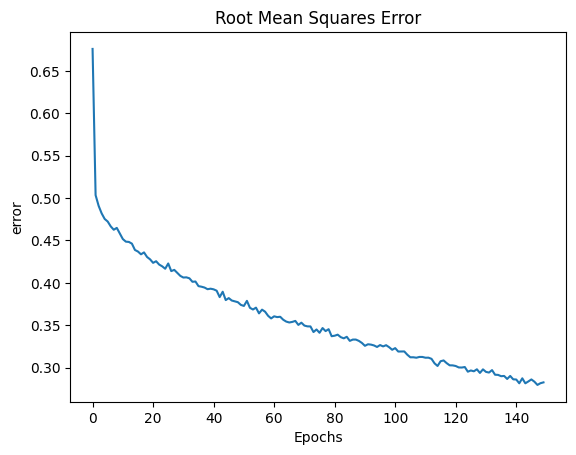

In [15]:
plt.plot(hist.history['root_mean_squared_error']) 
plt.title('Root Mean Squares Error') 
plt.xlabel('Epochs') 
plt.ylabel('error') 
plt.show() 


In [16]:
spfnet.evaluate(X_train, y_train)

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0713 - root_mean_squared_error: 0.2670


[0.06999538093805313, 0.2645663917064667]

In [17]:
from sklearn.metrics import mean_squared_error 
y_pred = spfnet.predict(X_test) 
y_pred_orig =sc_y.inverse_transform(y_pred) 
y_test_orig =sc_y.inverse_transform(y_test) 
RMSE_orig =mean_squared_error(y_pred_orig, y_test_orig, squared=False) 
RMSE_orig

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\harik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


np.float64(451.7611541520527)

Text(0.5, 1.0, 'Test Predictions vs Real Data')

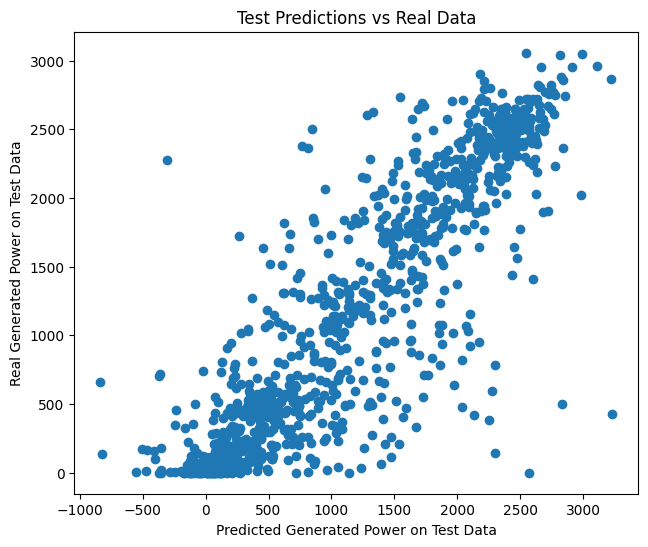

In [18]:
plt.figure(figsize=(16,6)) 
plt.subplot(1,2,2) 
plt.scatter(y_pred_orig, y_test_orig) 
plt.xlabel('Predicted Generated Power on Test Data') 
plt.ylabel('Real Generated Power on Test Data') 
plt.title('Test Predictions vs Real Data')